In [16]:
import pandas as pd
import numpy as np
pd.set_option('display.max_columns', None)

In [17]:
gt_ip = pd.read_csv('../data/processed/ehn_gt_inpatient_20251223000.csv')
gt_op = pd.read_csv('../data/processed/ehn_gt_outpatient_20251223000.csv')
risks = pd.read_csv('../data/processed/2024 Totals and Risk.csv')

/var/folders/v8/s4lwxw8s6wxbkhy0gqkmypnc0000gn/T/ipykernel_16902/615313613.py:3: DtypeWarning: Columns (5) have mixed types. Specify dtype option on import or set low_memory=False.
  risks = pd.read_csv('../data/processed/2024 Totals and Risk.csv')


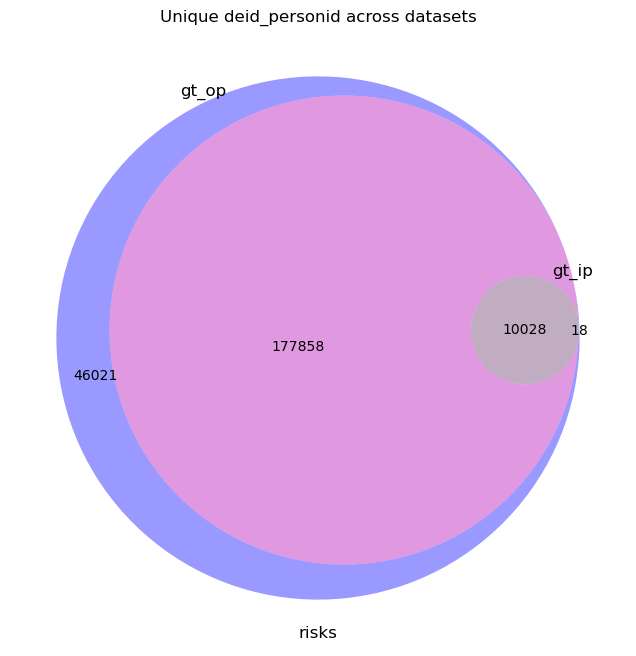

In [18]:
from matplotlib_venn import venn3

import matplotlib.pyplot as plt

# Get unique deid_personid from each dataframe
op_ids = set(gt_op.deid_personid.unique())
ip_ids = set(gt_ip.deid_personid.unique())
risk_ids = set(risks.deid_personid.unique())

# Create Venn diagram
plt.figure(figsize=(10, 8))
venn3([op_ids, ip_ids, risk_ids], set_labels=('gt_op', 'gt_ip', 'risks'))
plt.title('Unique deid_personid across datasets')
plt.show()

In [19]:
risks.columns

Index(['deid_personid', 'membermonths', 'payertype', 'city', 'state', 'zip',
       'pcpnpi', 'pcpname', 'ehn_vs_non', 'employed_vs_independent',
       'ehn_practice', 'lhn', 'entity', 'riskhcctotalrisk', 'riskhccclosed',
       'chronicconditionasthmaind', 'chronicconditionesrdind',
       'chronicconditionhfind', 'chronicconditioncrfind',
       'chronicconditionhypertensionind', 'chronicconditioncancerind',
       'chronicconditioncopdind', 'chronicconditiondiabetesind', 'costtotal',
       'countip', 'costip', 'ipreadmit', 'followup7daypcp', 'countop',
       'costop', 'counted', 'costed', 'countavoidableed', 'countretailrx',
       'costretailrx', 'lastvisitdate', 'lastvisitfacilityname'],
      dtype='object')

## ICD Mapping

In [20]:
ccsr = pd.read_csv('../data/raw/DXCCSR_v2026-1.csv')

# Standardize column names by stripping quotes and whitespace
ccsr.columns = ccsr.columns.astype(str).str.strip("'\"")

# Standardize ICD-10-CM codes by removing surrounding quotes and dots, and uppercasing
ccsr["icd10cm_code_std"] = (
    ccsr['ICD-10-CM CODE']
    .astype(str)
    .str.strip("'\"")
    .str.replace(".", "", regex=False)
    .str.upper()
)

icd_col = "primary_icd"
ccsr_icd_col = "icd10cm_code_std"
ccsr_category_col = "Default CCSR CATEGORY IP"
ccsr_desc_col = "Default CCSR CATEGORY DESCRIPTION IP"

gt_ip[icd_col] = gt_ip[icd_col].str.replace(".", "", regex=False)

gt_ip = gt_ip.merge(
    ccsr[[ccsr_icd_col, ccsr_category_col, ccsr_desc_col]],
    left_on=icd_col,
    right_on=ccsr_icd_col,
    how="left"
)
# Top 20 most expensive IP CCSR categories (by total cost)

top_ccsr_ip_cost = (
    gt_ip.dropna(subset=[ccsr_category_col, ccsr_desc_col])
    .groupby([ccsr_category_col, ccsr_desc_col], as_index=False)["cost"]
    .sum()
    .rename(columns={"cost": "total_cost"})
    .sort_values("total_cost", ascending=False)
    .head(20)
)

top_categories = top_ccsr_ip_cost['Default CCSR CATEGORY IP'].tolist()

deid_personids_in_top_categories = gt_ip[gt_ip[ccsr_category_col].isin(top_categories)]['deid_personid'].unique()

# create flag in risks for when deid_personid is in top categories
risks['in_top_ip_ccsr_category'] = risks['deid_personid'].isin(deid_personids_in_top_categories).astype(int)

/var/folders/v8/s4lwxw8s6wxbkhy0gqkmypnc0000gn/T/ipykernel_16902/668718177.py:1: DtypeWarning: Columns (15,17) have mixed types. Specify dtype option on import or set low_memory=False.
  ccsr = pd.read_csv('../data/raw/DXCCSR_v2026-1.csv')


In [21]:
cd_col = "primary_icd"
ccsr_icd_col = "icd10cm_code_std"
ccsr_category_col = "Default CCSR CATEGORY OP"
ccsr_desc_col = "Default CCSR CATEGORY DESCRIPTION OP"

gt_op[icd_col] = gt_op[icd_col].str.replace(".", "", regex=False)

gt_op = gt_op.merge(
    ccsr[[ccsr_icd_col, ccsr_category_col, ccsr_desc_col]],
    left_on=icd_col,
    right_on=ccsr_icd_col,
    how="left"
)
# Top 20 most expensive OP CCSR categories (by total cost)

top_ccsr_op_cost = (
    gt_op.dropna(subset=[ccsr_category_col, ccsr_desc_col])
    .groupby([ccsr_category_col, ccsr_desc_col], as_index=False)["cost"]
    .sum()
    .rename(columns={"cost": "total_cost"})
    .sort_values("total_cost", ascending=False)
    .head(20)
)

top_categories = top_ccsr_op_cost['Default CCSR CATEGORY OP'].tolist()

deid_personids_in_top_categories = gt_op[gt_op[ccsr_category_col].isin(top_categories)]['deid_personid'].unique()

# create flag in risks for when deid_personid is in top categories
risks['in_top_op_ccsr_category'] = risks['deid_personid'].isin(deid_personids_in_top_categories).astype(int)

#### Calculate cost per mm

In [22]:
cost_cols = [col for col in risks.columns if col.startswith("cost")]
for col in cost_cols:
    risks[f"{col}_mm"] = np.where(
        risks["membermonths"] > 0, risks[col] / risks["membermonths"], np.nan
    )

risks[[f"{col}_mm" for col in cost_cols]].describe()

,costtotal_mm,costip_mm,costop_mm,costed_mm,costretailrx_mm
count,293719.000000,293719.000000,293719.000000,293719.000000,293719.000000
mean,823.509773,157.614876,535.304778,37.250629,130.596984
std,3373.868167,1929.331786,2257.500659,288.214890,920.894262
min,0.000000,0.000000,0.000000,0.000000,0.000000
25%,40.231667,0.000000,33.802917,0.000000,0.000000
50%,166.025833,0.000000,137.659167,0.000000,0.000000
75%,555.890076,0.000000,407.459886,0.000000,7.551667
max,253124.716667,223984.875000,161248.292500,37494.833333,63321.130000


## Calculate Comorbidity Score based on ICDs

In [23]:
from comorbidipy import comorbidity, ScoreType, MappingVariant, WeightingVariant
from polars import from_pandas

comorbidity_op = comorbidity(from_pandas(gt_op[["deid_personid", "primary_icd"]]),
                            id_col="deid_personid",
                            code_col="primary_icd",
                            score=ScoreType.CHARLSON,
                            variant=MappingVariant.QUAN,
                            weighting=WeightingVariant.CHARLSON,)
comorbidity_ip = comorbidity(from_pandas(gt_ip[["deid_personid", "primary_icd"]]),
                            id_col="deid_personid",
                            code_col="primary_icd",
                            score=ScoreType.CHARLSON,
                            variant=MappingVariant.QUAN,
                            weighting=WeightingVariant.CHARLSON,)

result_op = comorbidity_op.to_pandas()
result_ip = comorbidity_ip.to_pandas()

# merge op and ip scores, keep all deid_personid, fill missing scores with 0, and keep highest score for each deid_personid
result = pd.merge(result_op, result_ip, on="deid_personid", how="outer", suffixes=("_op", "_ip"))
result["comorbidity_score"] = result[["comorbidity_score_op", "comorbidity_score_ip"]].max(axis=1).fillna(0).astype(int)
result = result[["deid_personid", "comorbidity_score"]]

In [24]:
# merge result back to risks, drop original comorbidity_score if it exists, fill missing scores with 0, and convert to int

risks = risks.drop(columns=["comorbidity_score"], errors="ignore").merge(result, on="deid_personid", how="left")
risks["comorbidity_score"] = risks["comorbidity_score"].fillna(0).astype(int)

## Cost Model

### Decision Tree, Forest, and XGB test

In [25]:
# # Check for missing values in risk score columns
# print("Missing values in risk score columns:")
# print(f"riskhcctotalrisk: {risks['riskhcctotalrisk'].isna().sum()}")
# print(f"riskhccclosed: {risks['riskhccclosed'].isna().sum()}")

# # Fill missing risk scores with median
# risks['riskhcctotalrisk'] = risks['riskhcctotalrisk'].fillna(risks['riskhcctotalrisk'].median())
# risks['riskhccclosed'] = risks['riskhccclosed'].fillna(risks['riskhccclosed'].median())

# # Verify no more missing values
# print("\nAfter filling:")
# print(f"riskhcctotalrisk: {risks['riskhcctotalrisk'].isna().sum()}")
# print(f"riskhccclosed: {risks['riskhccclosed'].isna().sum()}")

In [50]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

feature_cols = [
    "chronicconditionasthmaind",
    "chronicconditionesrdind",
    "chronicconditionhfind",
    "chronicconditioncrfind",
    "chronicconditionhypertensionind",
    "chronicconditioncancerind",
    "chronicconditioncopdind",
    "chronicconditiondiabetesind",
    # "riskhcctotalrisk",
    # "riskhccclosed",
    "in_top_ip_ccsr_category",
    "in_top_op_ccsr_category",
    # "countip",
    # "countop",
    "counted",
    "countavoidableed",
    "countretailrx",
    "comorbidity_score",

]

X = risks[feature_cols]
y = np.log1p(risks["costtotal_mm"]) # Use log transformation to reduce skewness

corr = X.corr()
corr

vif_df = pd.DataFrame(
    {
        "feature": X.columns,
        "vif": [variance_inflation_factor(X.values, i) for i in range(X.shape[1])],
    }
).sort_values("vif", ascending=False)

vif_df

,feature,vif
10,counted,2.982814
11,countavoidableed,2.850868
4,chronicconditionhypertensionind,2.322109
13,comorbidity_score,2.253365
9,in_top_op_ccsr_category,1.965875
12,countretailrx,1.727173
7,chronicconditiondiabetesind,1.668757
3,chronicconditioncrfind,1.568372
5,chronicconditioncancerind,1.334442
2,chronicconditionhfind,1.273412



XGBoost Calibration Table (Predicted Cost Buckets)


/var/folders/v8/s4lwxw8s6wxbkhy0gqkmypnc0000gn/T/ipykernel_16902/2441112555.py:94: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby("pred_group")


,pred_group,mean_actual_cost,mean_predicted_cost,count
0,<250,370.713735,78.497002,40174
1,250–500,981.713800,366.339142,9192
2,500–750,1417.187894,603.853760,4094
3,750–1000,1797.196535,855.252319,1851
4,1000–1500,2563.064231,1211.732178,1532
5,1500–2000,3783.082831,1725.020386,529
6,2000–2500,6456.772849,2225.742432,286
7,2500–3000,4989.495667,2757.197998,304
8,3000–4000,4909.546787,3437.756592,418
9,4000–5000,6923.741499,4463.453125,191


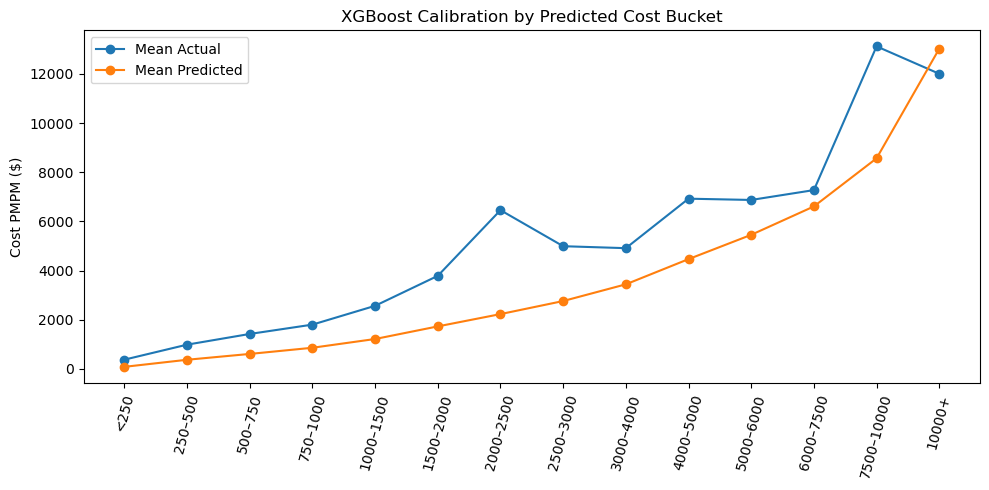

{'decision_tree_rmse': 1.939307674299275,
 'decision_tree_r2': 0.3447127147096417,
 'random_forest_rmse': 1.9207679385304,
 'random_forest_r2': 0.35718188802042705,
 'xgb_rmse': 1.9167296691074402,
 'xgb_r2': 0.3598819996382916}

In [51]:
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import root_mean_squared_error, r2_score
from xgboost import XGBRegressor

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

results = {}

# -----------------------
# Decision Tree
# -----------------------
dt = DecisionTreeRegressor(random_state=42)
dt.fit(X_train, y_train)

dt_pred = dt.predict(X_test)

results["decision_tree_rmse"] = root_mean_squared_error(y_test, dt_pred)
results["decision_tree_r2"] = r2_score(y_test, dt_pred)

# -----------------------
# Random Forest
# -----------------------
rf = RandomForestRegressor(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)
rf.fit(X_train, y_train)

rf_pred = rf.predict(X_test)

results["random_forest_rmse"] = root_mean_squared_error(y_test, rf_pred)
results["random_forest_r2"] = r2_score(y_test, rf_pred)

# -----------------------
# XGBoost
# -----------------------
try:
    xgb = XGBRegressor(
        n_estimators=300,
        max_depth=4,
        learning_rate=0.1,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42,
        n_jobs=-1,
    )
    xgb.fit(X_train, y_train)

    xgb_pred = xgb.predict(X_test)

    results["xgb_rmse"] = root_mean_squared_error(y_test, xgb_pred)
    results["xgb_r2"] = r2_score(y_test, xgb_pred)

    # =========================================================
    # Calibration-style grouping table FOR XGBOOST predictions
    # =========================================================

    # Convert log scale back to dollars
    y_test_dollars = np.expm1(y_test)
    xgb_pred_dollars = np.expm1(xgb_pred)

    df_eval_xgb = pd.DataFrame({
        "actual_cost": y_test_dollars,
        "predicted_cost": xgb_pred_dollars
    })

    bins = [
        0, 250, 500, 750, 1000, 1500, 2000, 2500,
        3000, 4000, 5000, 6000, 7500, 10000, np.inf
    ]

    labels = [
        "<250", "250–500", "500–750", "750–1000",
        "1000–1500", "1500–2000", "2000–2500",
        "2500–3000", "3000–4000", "4000–5000",
        "5000–6000", "6000–7500", "7500–10000",
        "10000+"
    ]

    df_eval_xgb["pred_group"] = pd.cut(
        df_eval_xgb["predicted_cost"],
        bins=bins,
        labels=labels,
        right=False
    )

    xgb_group_table = (
        df_eval_xgb
        .groupby("pred_group")
        .agg(
            mean_actual_cost=("actual_cost", "mean"),
            mean_predicted_cost=("predicted_cost", "mean"),
            count=("actual_cost", "size")
        )
        .reset_index()
    )

    print("\nXGBoost Calibration Table (Predicted Cost Buckets)")
    display(xgb_group_table)

    # Optional: plot mean actual vs mean predicted by bucket
    plt.figure(figsize=(10, 5))
    plt.plot(xgb_group_table["pred_group"].astype(str),
             xgb_group_table["mean_actual_cost"],
             marker="o", label="Mean Actual")
    plt.plot(xgb_group_table["pred_group"].astype(str),
             xgb_group_table["mean_predicted_cost"],
             marker="o", label="Mean Predicted")
    plt.xticks(rotation=75)
    plt.ylabel("Cost PMPM ($)")
    plt.title("XGBoost Calibration by Predicted Cost Bucket")
    plt.legend()
    plt.tight_layout()
    plt.show()

    top_group = df_eval_xgb[df_eval_xgb["pred_group"] == "50000+"]
    lift_share = top_group["actual_cost"].sum() / df_eval_xgb["actual_cost"].sum()

except Exception as e:
    results["xgb_error"] = str(e)

results

https://pmc.ncbi.nlm.nih.gov/articles/PMC4194673/#sec20

Mean actual cost increases monotonically across predicted buckets. This indicates that the model effectively ranks members by relative spending risk. Higher predicted groups correspond to progressively higher realized costs, demonstrating meaningful discriminatory power.


The model tends to underpredict costs

In [40]:
importance_df = pd.DataFrame({"feature": feature_cols})

importance_df["decision_tree"] = dt.feature_importances_
importance_df["random_forest"] = rf.feature_importances_

if "xgb" in globals():
    importance_df["xgb"] = xgb.feature_importances_

importance_df = importance_df.set_index("feature").sort_values(
    by="random_forest", ascending=False
)

importance_df

,decision_tree,random_forest,xgb
feature,,,
countop,0.813826,0.809289,0.523743
countretailrx,0.077556,0.079645,0.092982
countip,0.041718,0.039305,0.100351
comorbidity_score,0.011903,0.013115,0.019325
in_top_op_ccsr_category,0.012194,0.012796,0.090729
counted,0.010775,0.011049,0.075121
chronicconditionhypertensionind,0.005393,0.006205,0.027066
chronicconditiondiabetesind,0.004654,0.005138,0.006374
chronicconditioncrfind,0.004395,0.004828,0.001895


## High-Cost Patient Classification (Top 10% Model)

/opt/miniconda3/envs/data_6748/lib/python3.14/site-packages/sklearn/linear_model/_logistic.py:1184: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=-1', please leave it unspecified.
  warnings.warn(msg, category=FutureWarning)


{'logistic_regression_auc': 0.917620894660772, 'gradient_boosting_auc': 0.9232207065222328}

Using custom threshold = 0.2

Logistic Regression Classification Report
              precision    recall  f1-score   support

           0       0.96      0.95      0.96     52870
           1       0.59      0.63      0.61      5874

    accuracy                           0.92     58744
   macro avg       0.78      0.79      0.78     58744
weighted avg       0.92      0.92      0.92     58744


Gradient Boosting Classification Report
              precision    recall  f1-score   support

           0       0.96      0.93      0.95     52870
           1       0.53      0.69      0.60      5874

    accuracy                           0.91     58744
   macro avg       0.75      0.81      0.77     58744
weighted avg       0.92      0.91      0.91     58744

Logistic Regression Confusion Matrix


,Pred 0,Pred 1
Actual 0,50358,2512
Actual 1,2201,3673


Gradient Boosting Confusion Matrix


,Pred 0,Pred 1
Actual 0,49231,3639
Actual 1,1811,4063


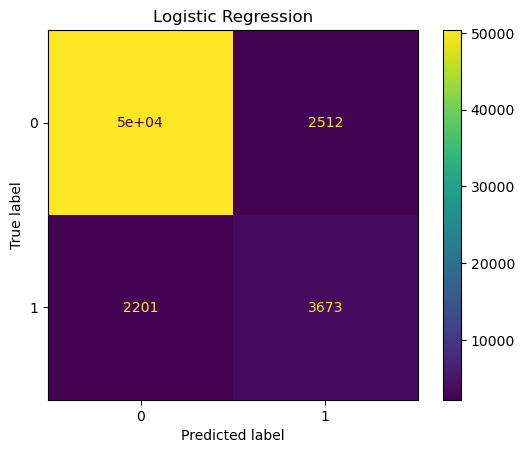

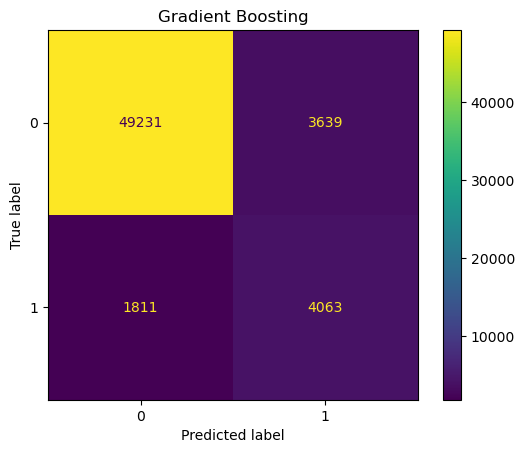

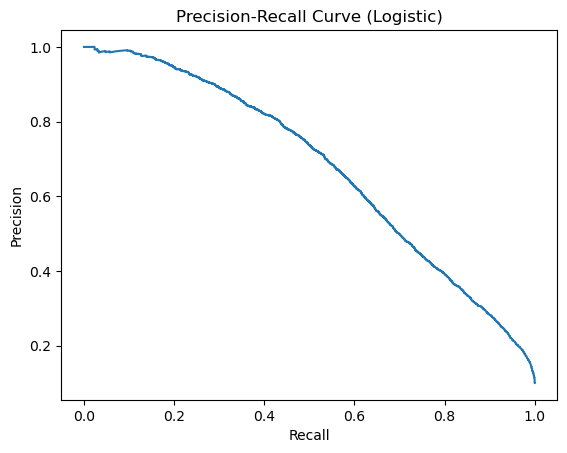

In [41]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import (
    roc_auc_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    precision_recall_curve
)
from sklearn.model_selection import train_test_split
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# -------------------------------
# Define high-cost label
# -------------------------------
threshold = risks["costtotal"].quantile(0.90)
y_highcost = (risks["costtotal"] >= threshold).astype(int)

# -------------------------------
# Train-test split
# -------------------------------
X_train_hc, X_test_hc, y_train_hc, y_test_hc = train_test_split(
    X, y_highcost,
    test_size=0.2,
    random_state=42,
    stratify=y_highcost
)

# -------------------------------
# Logistic Regression
# -------------------------------
log_reg = LogisticRegression(
    max_iter=1000,
    # class_weight="auto",
    n_jobs=-1
)
log_reg.fit(X_train_hc, y_train_hc)

lr_probs = log_reg.predict_proba(X_test_hc)[:, 1]
log_reg_auc = roc_auc_score(y_test_hc, lr_probs)

# -------------------------------
# Gradient Boosting
# -------------------------------
gb_clf = GradientBoostingClassifier(
    n_estimators=300,        # increase from default 100
    learning_rate=0.05,      # lower from default 0.1
    max_depth=3,             # deeper trees (default is 3 inside base tree)
    random_state=42
)
gb_clf.fit(X_train_hc, y_train_hc)

gb_probs = gb_clf.predict_proba(X_test_hc)[:, 1]
gb_auc = roc_auc_score(y_test_hc, gb_probs)

print({
    "logistic_regression_auc": log_reg_auc,
    "gradient_boosting_auc": gb_auc,
})

# -------------------------------
# Custom threshold tuning
# -------------------------------

# Choose a lower threshold to improve recall
custom_threshold = 0.20

y_pred_lr = (lr_probs >= custom_threshold).astype(int)
y_pred_gb = (gb_probs >= custom_threshold).astype(int)

print(f"\nUsing custom threshold = {custom_threshold}")

print("\nLogistic Regression Classification Report")
print(classification_report(y_test_hc, y_pred_lr))

print("\nGradient Boosting Classification Report")
print(classification_report(y_test_hc, y_pred_gb))

# -------------------------------
# Confusion matrices
# -------------------------------

cm_lr = confusion_matrix(y_test_hc, y_pred_lr, labels=[0, 1])
cm_gb = confusion_matrix(y_test_hc, y_pred_gb, labels=[0, 1])

print("Logistic Regression Confusion Matrix")
display(pd.DataFrame(cm_lr, index=["Actual 0", "Actual 1"], columns=["Pred 0", "Pred 1"]))

print("Gradient Boosting Confusion Matrix")
display(pd.DataFrame(cm_gb, index=["Actual 0", "Actual 1"], columns=["Pred 0", "Pred 1"]))

ConfusionMatrixDisplay(cm_lr, display_labels=[0, 1]).plot()
plt.title("Logistic Regression")
plt.show()

ConfusionMatrixDisplay(cm_gb, display_labels=[0, 1]).plot()
plt.title("Gradient Boosting")
plt.show()

# -------------------------------
# Precision-Recall curve
# -------------------------------

precision, recall, thresholds = precision_recall_curve(y_test_hc, lr_probs)

plt.plot(recall, precision)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve (Logistic)")
plt.show()

## Prob of IP admission

In [42]:
# from sklearn.linear_model import LogisticRegression
# from sklearn.metrics import (
#     roc_auc_score,
#     classification_report,
#     confusion_matrix,
#     ConfusionMatrixDisplay,
#     precision_recall_curve
# )
# from sklearn.model_selection import train_test_split
# from sklearn.preprocessing import StandardScaler
# from sklearn.pipeline import Pipeline
# import matplotlib.pyplot as plt
# import pandas as pd
# import numpy as np

# # --------------------------------
# # Label inpatient admission
# # --------------------------------
# y_ip = risks["deid_personid"].isin(ip_ids).astype(int)

# print("Inpatient rate:", y_ip.mean())

# # --------------------------------
# # Train-test split (stratified)
# # --------------------------------
# X_train_ip, X_test_ip, y_train_ip, y_test_ip = train_test_split(
#     X, y_ip,
#     test_size=0.2,
#     random_state=42,
#     stratify=y_ip
# )

# # --------------------------------
# # Logistic regression with scaling + class weighting
# # --------------------------------
# ip_model = Pipeline([
#     ("scaler", StandardScaler()),
#     ("logreg", LogisticRegression(
#         max_iter=2000,
#         class_weight="balanced",
#         n_jobs=-1
#     ))
# ])

# ip_model.fit(X_train_ip, y_train_ip)

# # --------------------------------
# # Evaluate with probabilities
# # --------------------------------
# ip_probs = ip_model.predict_proba(X_test_ip)[:, 1]

# ip_auc = roc_auc_score(y_test_ip, ip_probs)
# print("ROC-AUC:", ip_auc)

# # --------------------------------
# # Custom threshold (instead of default 0.5)
# # --------------------------------
# custom_threshold = 0.30
# y_pred_ip = (ip_probs >= custom_threshold).astype(int)

# print(f"\nUsing threshold = {custom_threshold}")
# print(classification_report(y_test_ip, y_pred_ip))

# # --------------------------------
# # Confusion matrix
# # --------------------------------
# cm_ip = confusion_matrix(y_test_ip, y_pred_ip)

# display(pd.DataFrame(
#     cm_ip,
#     index=["Actual 0", "Actual 1"],
#     columns=["Pred 0", "Pred 1"]
# ))

# ConfusionMatrixDisplay(cm_ip).plot()
# plt.title("Inpatient Admission Model")
# plt.show()

# # --------------------------------
# # Precision-Recall Curve
# # --------------------------------
# precision, recall, thresholds = precision_recall_curve(y_test_ip, ip_probs)

# plt.plot(recall, precision)
# plt.xlabel("Recall")
# plt.ylabel("Precision")
# plt.title("Precision-Recall Curve (Inpatient)")
# plt.show()

# pd.Series(ip_probs).describe()